# Task 5 — Bias investigation and mitigation: family vs. non-family searches

This notebook investigates a possible **quality-of-service bias** in the hotel ranking model: whether the model performs differently for **family searches** compared with **non-family searches**.

A search is treated as a family search when it includes at least one child or more than one room:

```python
family_search = (srch_children_count > 0) or (srch_room_count > 1)
```

The notebook follows three steps:

1. Detect possible bias by comparing ranking performance between family and non-family searches.
2. Mitigate possible bias using **pre-processing re-weighting** of relevant family-search examples.
3. Evaluate whether mitigation improved family-search performance and what trade-off it caused in overall NDCG@5.

In [1]:
# ---------------------------------------------------
# Cell 1: Imports and settings
# ---------------------------------------------------

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# ---------------------------------------------------
# Cell 2: Load prepared Task 3 feature files
# ---------------------------------------------------
# This notebook assumes you already ran Task 3 and saved these files.

train_feat = pd.read_parquet("data/train_features.parquet")
val_feat = pd.read_parquet("data/val_features.parquet")

print("Train features:", train_feat.shape)
print("Validation features:", val_feat.shape)

display(train_feat.head())

Train features: (3980039, 177)
Validation features: (978308, 177)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,relevance,visitor_hist_starrating_missing,visitor_hist_adr_usd_missing,srch_query_affinity_score_missing,orig_destination_distance_missing,prop_location_score2_missing,prop_review_score_missing,prop_review_score_is_zero,prop_starrating_is_zero,price_is_zero,price_below_1,price_below_10,price_usd_capped,price_usd_clipped,log_price_usd,log_price_usd_capped,log_price_usd_clipped,log_orig_destination_distance,total_guests,children_present,multi_room,domestic_search,log_booking_window,log_length_of_stay,last_minute_booking,long_booking_window,long_stay,is_4_star,is_5_star,high_review_score,search_month,search_quarter,search_dayofweek,search_hour,search_is_weekend,comp_rate_missing_count,comp_inv_missing_count,comp_pct_missing_count,comp_has_any_rate_data,comp_has_any_inv_data,comp_has_any_pct_data,comp_expedia_cheaper_count,comp_expedia_more_expensive_count,comp_same_price_count,comp_unavailable_count,comp_available_count,comp1_rate_missing,comp1_inv_missing,comp1_rate_percent_diff_missing,comp2_rate_missing,comp2_inv_missing,comp2_rate_percent_diff_missing,comp3_rate_missing,comp3_inv_missing,comp3_rate_percent_diff_missing,comp4_rate_missing,comp4_inv_missing,comp4_rate_percent_diff_missing,comp5_rate_missing,comp5_inv_missing,comp5_rate_percent_diff_missing,comp6_rate_missing,comp6_inv_missing,comp6_rate_percent_diff_missing,comp7_rate_missing,comp7_inv_missing,comp7_rate_percent_diff_missing,comp8_rate_missing,comp8_inv_missing,comp8_rate_percent_diff_missing,comp_no_rate_data_count,comp_no_inv_data_count,hotels_in_search,search_price_mean,search_price_median,search_price_min,search_price_max,price_diff_from_search_mean,price_diff_from_search_median,price_diff_from_search_min,price_ratio_to_search_mean,price_ratio_to_search_median,price_rank_in_search,price_pct_rank_in_search,search_log_price_mean,log_price_diff_from_search_mean,search_star_mean,search_star_max,star_diff_from_search_mean,star_diff_from_search_max,star_rank_in_search,star_pct_rank_in_search,search_review_mean,search_review_max,review_diff_from_search_mean,review_diff_from_search_max,review_rank_in_search,review_pct_rank_in_search,search_location1_mean,search_location2_mean,location1_diff_from_search_mean,location2_diff_from_search_mean,location2_rank_in_search,location2_pct_rank_in_search,search_promotion_rate,promotion_above_search_avg,prop_id_count,prop_id_mean_price,prop_id_median_price,prop_id_std_price,prop_id_mean_log_price,prop_id_mean_starrating,prop_id_mean_review_score,prop_id_mean_location_score1,prop_id_mean_location_score2,prop_id_mean_promotion_flag,dest_id_count,dest_id_mean_price,dest_id_median_price,dest_id_mean_starrating,dest_id_mean_review_score,dest_id_mean_location_score2,prop_dest_count
0,1,2013-04-04 08:32:15,12,187,-1.0,-1.0,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,-327.567505,392.559998,1,-2.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,0,NaN,0,0,1,1,1,1,0,0,0,0,0,0,0,104.769997,104.769997,4.661267,4.661267,4.661267,5.975234,4,0,0,0,0.0,0.693147,1,0,0,0,0,0,4,2,3,8,0,4,4,8,1,1,0,0,0,4,0,4,1,1,1,0

In [3]:
# ---------------------------------------------------
# Cell 3: Add family-search group indicator
# ---------------------------------------------------
# A family search is defined as a search with at least one child or more than one room.
# This matches the assignment example of possible variable performance across families vs. other users.

for df in [train_feat, val_feat]:
    df["family_search"] = (
        (df["srch_children_count"] > 0) |
        (df["srch_room_count"] > 1)
    ).astype(np.int8)

# Sanity check: family_search should be constant within each srch_id.
train_family_unique_per_search = train_feat.groupby("srch_id")["family_search"].nunique().max()
val_family_unique_per_search = val_feat.groupby("srch_id")["family_search"].nunique().max()

print("Max number of family labels per train search:", train_family_unique_per_search)
print("Max number of family labels per validation search:", val_family_unique_per_search)

family_summary = (
    val_feat.groupby("family_search")
    .agg(
        rows=("srch_id", "size"),
        searches=("srch_id", "nunique"),
        click_rate=("click_bool", "mean"),
        booking_rate=("booking_bool", "mean"),
        mean_relevance=("relevance", "mean"),
        mean_length_of_stay=("srch_length_of_stay", "mean"),
        mean_booking_window=("srch_booking_window", "mean"),
        mean_price=("price_usd", "mean")
    )
    .reset_index()
)

family_summary["group"] = np.where(
    family_summary["family_search"] == 1,
    "Family searches",
    "Non-family searches"
)

family_summary = family_summary[["group", "rows", "searches", "click_rate", "booking_rate", "mean_relevance", "mean_length_of_stay", "mean_booking_window", "mean_price"]]

display(family_summary)

Max number of family labels per train search: 1
Max number of family labels per validation search: 1


,group,rows,searches,click_rate,booking_rate,mean_relevance,mean_length_of_stay,mean_booking_window,mean_price
0,Non-family searches,662588,26436,0.044359,0.027747,0.155348,2.327611,31.222081,300.959010
1,Family searches,315720,13523,0.046829,0.030366,0.168292,2.448258,33.054780,466.665546


In [4]:
# ---------------------------------------------------
# Cell 4: Build feature list exactly as in Task 4
# ---------------------------------------------------
# We exclude identifiers, target variables, training-only variables, and date_time.
# family_search is already part of the engineered feature set if created in Task 3,
# but even if not, it is now available and can be used as a normal context feature.

NON_FEATURE_COLS = [
    "srch_id",
    "prop_id",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
    "relevance"
]

feature_cols = [
    col for col in train_feat.columns
    if col not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(train_feat[col])
]

missing_in_val = [col for col in feature_cols if col not in val_feat.columns]
if missing_in_val:
    raise ValueError(f"Validation set is missing these feature columns: {missing_in_val}")

print("Number of model features:", len(feature_cols))
print("First 40 features:")
print(feature_cols[:40])

Number of model features: 170
First 40 features:
['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv']


In [5]:
# ---------------------------------------------------
# Cell 5: Sort by search ID and create model matrices
# ---------------------------------------------------
# LightGBM ranker needs rows sorted by group.

train_feat = train_feat.sort_values("srch_id").reset_index(drop=True)
val_feat = val_feat.sort_values("srch_id").reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["relevance"].astype(int)
group_train = train_feat.groupby("srch_id").size().to_numpy()

X_val = val_feat[feature_cols]
y_val = val_feat["relevance"].astype(int)
group_val = val_feat.groupby("srch_id").size().to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of train search groups:", len(group_train))
print("Number of validation search groups:", len(group_val))

X_train: (3980039, 170)
X_val: (978308, 170)
Number of train search groups: 159836
Number of validation search groups: 39959


In [6]:
# ---------------------------------------------------
# Cell 6: Define ranking evaluation functions
# ---------------------------------------------------

def dcg_at_k(relevances, k=5):
    """Compute DCG@k for one ranked list."""
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    gains = (2 ** relevances - 1)
    return float(np.sum(gains / discounts))


def ndcg_at_k_for_group(y_true, y_score, k=5):
    """Compute NDCG@k for one search group."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)
    ranked_relevance = y_true[order]

    ideal_order = np.argsort(-y_true)
    ideal_relevance = y_true[ideal_order]

    dcg = dcg_at_k(ranked_relevance, k=k)
    idcg = dcg_at_k(ideal_relevance, k=k)

    if idcg == 0:
        return 0.0
    return dcg / idcg


def mean_ndcg_at_k(df, y_true_col="relevance", y_score_col="score", group_col="srch_id", k=5):
    """Compute mean NDCG@k over all searches."""
    scores = []
    for _, group in df.groupby(group_col, sort=False):
        scores.append(
            ndcg_at_k_for_group(
                group[y_true_col].to_numpy(),
                group[y_score_col].to_numpy(),
                k=k
            )
        )
    return float(np.mean(scores))

In [7]:
# ---------------------------------------------------
# Cell 7: Define family-bias evaluation function
# ---------------------------------------------------
# This computes search-level ranking metrics separately for family and non-family searches.


def evaluate_family_search_performance(df, score_col="score", k=5):
    """
    Evaluate ranking quality separately for family and non-family searches.

    Metrics:
    - ndcg@5: average NDCG@5 for each group of searches.
    - booked_recall@5: among searches with a booking, whether any booked hotel is in top 5.
    - booked_top1_hit: among searches with a booking, whether a booked hotel is ranked first.
    - mean_booked_rank: average rank position of the booked hotel, lower is better.
    """
    rows = []

    for srch_id, group in df.groupby("srch_id", sort=False):
        family = int(group["family_search"].iloc[0])
        group_name = "Family searches" if family == 1 else "Non-family searches"

        sorted_group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        sorted_group["rank"] = np.arange(1, len(sorted_group) + 1)

        ndcg = ndcg_at_k_for_group(
            sorted_group["relevance"].to_numpy(),
            sorted_group[score_col].to_numpy(),
            k=k
        )

        has_booking = bool((sorted_group["booking_bool"] == 1).any())

        if has_booking:
            booked_ranks = sorted_group.loc[sorted_group["booking_bool"] == 1, "rank"].to_numpy()
            best_booked_rank = int(booked_ranks.min())
            booked_recall_at_k = int(best_booked_rank <= k)
            booked_top1_hit = int(best_booked_rank == 1)
        else:
            best_booked_rank = np.nan
            booked_recall_at_k = np.nan
            booked_top1_hit = np.nan

        rows.append({
            "srch_id": srch_id,
            "group": group_name,
            "family_search": family,
            "ndcg@5": ndcg,
            "has_booking": has_booking,
            "booked_recall@5": booked_recall_at_k,
            "booked_top1_hit": booked_top1_hit,
            "booked_rank": best_booked_rank
        })

    search_metrics = pd.DataFrame(rows)

    summary = (
        search_metrics
        .groupby("group")
        .agg(
            num_searches=("srch_id", "count"),
            num_booked_searches=("has_booking", "sum"),
            mean_ndcg_at_5=("ndcg@5", "mean"),
            booked_recall_at_5=("booked_recall@5", "mean"),
            booked_top1_hit_rate=("booked_top1_hit", "mean"),
            mean_booked_rank=("booked_rank", "mean")
        )
        .reset_index()
    )

    return summary, search_metrics


def add_gap_row(summary_df, model_name):
    """Create one compact row with family minus non-family performance gaps."""
    tmp = summary_df.set_index("group")

    family = tmp.loc["Family searches"]
    non_family = tmp.loc["Non-family searches"]

    return {
        "model": model_name,
        "overall_ndcg@5": np.nan,
        "family_ndcg@5": family["mean_ndcg_at_5"],
        "non_family_ndcg@5": non_family["mean_ndcg_at_5"],
        "family_minus_non_family_ndcg@5": family["mean_ndcg_at_5"] - non_family["mean_ndcg_at_5"],
        "family_booked_recall@5": family["booked_recall_at_5"],
        "non_family_booked_recall@5": non_family["booked_recall_at_5"],
        "family_minus_non_family_recall@5": family["booked_recall_at_5"] - non_family["booked_recall_at_5"],
        "family_top1_hit_rate": family["booked_top1_hit_rate"],
        "non_family_top1_hit_rate": non_family["booked_top1_hit_rate"],
        "family_mean_booked_rank": family["mean_booked_rank"],
        "non_family_mean_booked_rank": non_family["mean_booked_rank"],
        "num_family_searches": int(family["num_searches"]),
        "num_non_family_searches": int(non_family["num_searches"]),
        "num_family_booked_searches": int(family["num_booked_searches"]),
        "num_non_family_booked_searches": int(non_family["num_booked_searches"])
    }

In [8]:
# ---------------------------------------------------
# Cell 8: Train original LightGBM Ranker
# ---------------------------------------------------
# These are the best parameters found in Task 4.

best_parameters = {
    "num_leaves": 383,
    "learning_rate": 0.02,
    "min_child_samples": 900,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 286
}

original_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

original_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[
        lgb.log_evaluation(period=100)
    ]
)

print("Original model trained.")

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.463273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16590
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 169
[100]	valid_0's ndcg@5: 0.383656
[200]	valid_0's ndcg@5: 0.38558
Original model trained.


In [9]:
# ---------------------------------------------------
# Cell 9: Evaluate original model for family-search bias
# ---------------------------------------------------

val_original = val_feat[[
    "srch_id",
    "prop_id",
    "family_search",
    "relevance",
    "booking_bool",
    "click_bool"
]].copy()

val_original["score"] = original_ranker.predict(X_val)

original_overall_ndcg = mean_ndcg_at_k(
    val_original,
    y_true_col="relevance",
    y_score_col="score",
    group_col="srch_id",
    k=K
)

original_group_summary, original_search_metrics = evaluate_family_search_performance(
    val_original,
    score_col="score",
    k=K
)

original_metrics = add_gap_row(original_group_summary, "Original LightGBM Ranker")
original_metrics["overall_ndcg@5"] = original_overall_ndcg

print("Original overall NDCG@5:", original_overall_ndcg)
display(original_group_summary)
display(pd.DataFrame([original_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Original overall NDCG@5: 0.3872653857390874


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Family searches,13523,9587,0.397068,0.599979,0.222697,6.578283
1,Non-family searches,26436,18385,0.382251,0.589394,0.220723,6.700082


,value
model,Original LightGBM Ranker
overall_ndcg@5,0.387265
family_ndcg@5,0.397068
non_family_ndcg@5,0.382251
family_minus_non_family_ndcg@5,0.014818
family_booked_recall@5,0.599979
non_family_booked_recall@5,0.589394
family_minus_non_family_recall@5,0.010586
family_top1_hit_rate,0.222697
non_family_top1_hit_rate,0.220723


In [10]:
# ---------------------------------------------------
# Cell 10: Create pre-processing re-weighting scheme
# ---------------------------------------------------
# Mitigation idea:
# If family searches are underserved, give more weight to relevant hotels in family searches.
# This makes errors on clicked/booked family-search hotels matter more during training.
#
# You can tune these weights. Start with moderate weights to avoid overcorrection.

sample_weight_family = np.ones(len(train_feat), dtype=np.float32)

# Clicked or booked hotels in family searches receive slightly higher weight.
sample_weight_family[
    (train_feat["family_search"] == 1) &
    (train_feat["relevance"] > 0)
] = 1.25

# Booked hotels in family searches receive the highest weight.
sample_weight_family[
    (train_feat["family_search"] == 1) &
    (train_feat["relevance"] == 5)
] = 1.50

weight_summary = (
    pd.Series(sample_weight_family, name="weight")
    .value_counts()
    .sort_index()
    .reset_index()
)
weight_summary.columns = ["weight", "count"]
weight_summary["share"] = weight_summary["count"] / len(sample_weight_family)

display(weight_summary)

,weight,count,share
0,1.00,3929645,0.987338
1,1.25,18527,0.004655
2,1.50,31867,0.008007


In [11]:
# ---------------------------------------------------
# Cell 11: Train mitigated re-weighted LightGBM Ranker
# ---------------------------------------------------
# This model uses exactly the same hyperparameters as the original model.
# The only difference is sample_weight_family.

family_weighted_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

family_weighted_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    sample_weight=sample_weight_family,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[
        lgb.log_evaluation(period=100)
    ]
)

print("Family re-weighted model trained.")

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.554043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16590
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 169
[100]	valid_0's ndcg@5: 0.381037
[200]	valid_0's ndcg@5: 0.382024
Family re-weighted model trained.


In [12]:
# ---------------------------------------------------
# Cell 12: Evaluate mitigated model
# ---------------------------------------------------

val_fair = val_feat[[
    "srch_id",
    "prop_id",
    "family_search",
    "relevance",
    "booking_bool",
    "click_bool"
]].copy()

val_fair["score"] = family_weighted_ranker.predict(X_val)

fair_overall_ndcg = mean_ndcg_at_k(
    val_fair,
    y_true_col="relevance",
    y_score_col="score",
    group_col="srch_id",
    k=K
)

fair_group_summary, fair_search_metrics = evaluate_family_search_performance(
    val_fair,
    score_col="score",
    k=K
)

fair_metrics = add_gap_row(fair_group_summary, "Family re-weighted LightGBM Ranker")
fair_metrics["overall_ndcg@5"] = fair_overall_ndcg

print("Family re-weighted overall NDCG@5:", fair_overall_ndcg)
display(fair_group_summary)
display(pd.DataFrame([fair_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Family re-weighted overall NDCG@5: 0.38194072349435176


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Family searches,13523,9587,0.383515,0.587254,0.206634,6.814228
1,Non-family searches,26436,18385,0.381136,0.590318,0.219037,6.702366


,value
model,Family re-weighted LightGBM Ranker
overall_ndcg@5,0.381941
family_ndcg@5,0.383515
non_family_ndcg@5,0.381136
family_minus_non_family_ndcg@5,0.002379
family_booked_recall@5,0.587254
non_family_booked_recall@5,0.590318
family_minus_non_family_recall@5,-0.003065
family_top1_hit_rate,0.206634
non_family_top1_hit_rate,0.219037


In [13]:
# ---------------------------------------------------
# Cell 13: Compare original and mitigated models
# ---------------------------------------------------

comparison_df = pd.DataFrame([original_metrics, fair_metrics])

numeric_cols = [col for col in comparison_df.columns if col != "model"]
comparison_df[numeric_cols] = comparison_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
comparison_display = comparison_df.copy()
comparison_display[numeric_cols] = comparison_display[numeric_cols].round(6)

display(comparison_display)
display(comparison_display.T)

# A smaller report-ready subset.
report_cols = [
    "model",
    "overall_ndcg@5",
    "family_ndcg@5",
    "non_family_ndcg@5",
    "family_minus_non_family_ndcg@5",
    "family_booked_recall@5",
    "non_family_booked_recall@5",
    "family_minus_non_family_recall@5",
    "family_top1_hit_rate",
    "non_family_top1_hit_rate",
    "family_mean_booked_rank",
    "non_family_mean_booked_rank"
]

display(comparison_display[report_cols])

,model,overall_ndcg@5,family_ndcg@5,non_family_ndcg@5,family_minus_non_family_ndcg@5,family_booked_recall@5,non_family_booked_recall@5,family_minus_non_family_recall@5,family_top1_hit_rate,non_family_top1_hit_rate,family_mean_booked_rank,non_family_mean_booked_rank,num_family_searches,num_non_family_searches,num_family_booked_searches,num_non_family_booked_searches
0,Original LightGBM Ranker,0.387265,0.397068,0.382251,0.014818,0.599979,0.589394,0.010586,0.222697,0.220723,6.578283,6.700082,13523,26436,9587,18385
1,Family re-weighted LightGBM Ranker,0.381941,0.383515,0.381136,0.002379,0.587254,0.590318,-0.003065,0.206634,0.219037,6.814228,6.702366,13523,26436,9587,18385


,0,1
model,Original LightGBM Ranker,Family re-weighted LightGBM Ranker
overall_ndcg@5,0.387265,0.381941
family_ndcg@5,0.397068,0.383515
non_family_ndcg@5,0.382251,0.381136
family_minus_non_family_ndcg@5,0.014818,0.002379
family_booked_recall@5,0.599979,0.587254
non_family_booked_recall@5,0.589394,0.590318
family_minus_non_family_recall@5,0.010586,-0.003065
family_top1_hit_rate,0.222697,0.206634
non_family_top1_hit_rate,0.220723,0.219037


,model,overall_ndcg@5,family_ndcg@5,non_family_ndcg@5,family_minus_non_family_ndcg@5,family_booked_recall@5,non_family_booked_recall@5,family_minus_non_family_recall@5,family_top1_hit_rate,non_family_top1_hit_rate,family_mean_booked_rank,non_family_mean_booked_rank
0,Original LightGBM Ranker,0.387265,0.397068,0.382251,0.014818,0.599979,0.589394,0.010586,0.222697,0.220723,6.578283,6.700082
1,Family re-weighted LightGBM Ranker,0.381941,0.383515,0.381136,0.002379,0.587254,0.590318,-0.003065,0.206634,0.219037,6.814228,6.702366


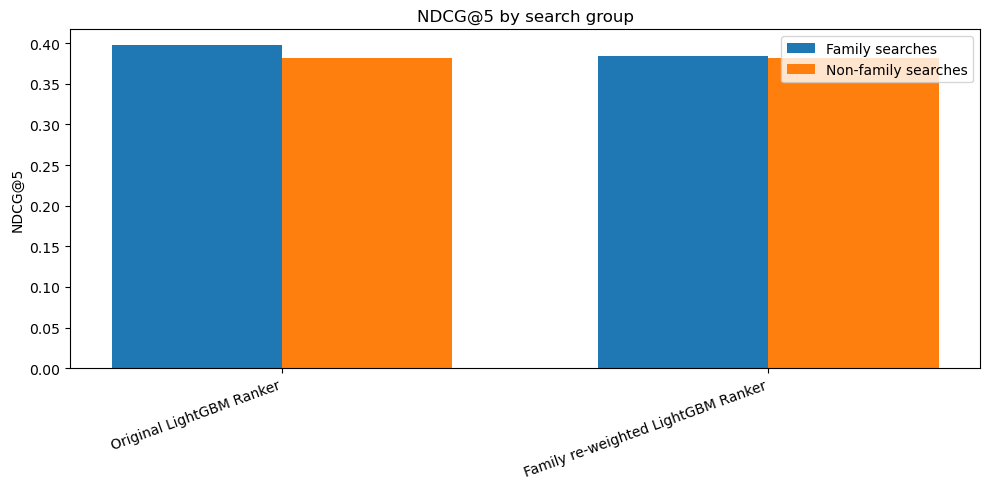

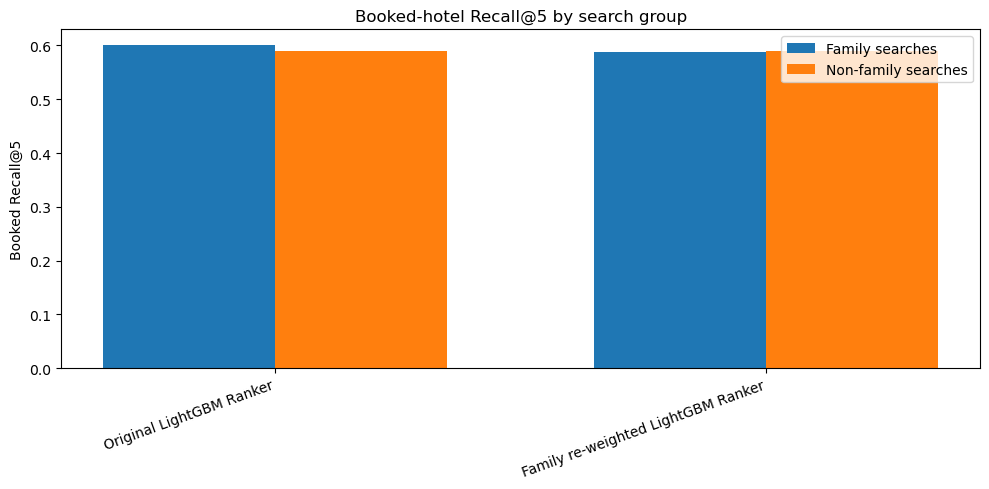

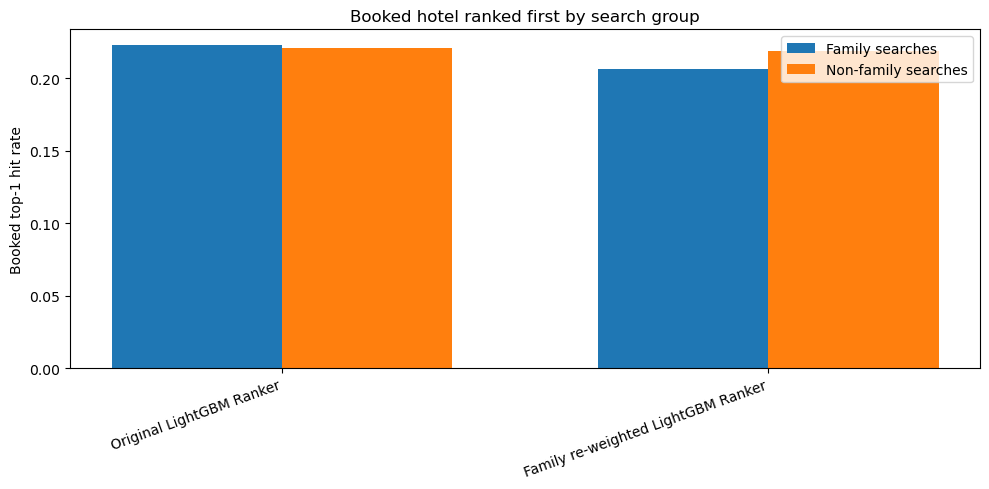

In [14]:
# ---------------------------------------------------
# Cell 14: Visualise original vs. mitigated group performance
# ---------------------------------------------------

plot_df = comparison_df.copy()

# NDCG@5 comparison
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, plot_df["family_ndcg@5"], width, label="Family searches")
ax.bar(x + width/2, plot_df["non_family_ndcg@5"], width, label="Non-family searches")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylabel("NDCG@5")
ax.set_title("NDCG@5 by search group")
ax.legend()
plt.tight_layout()
plt.show()

# Booked Recall@5 comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, plot_df["family_booked_recall@5"], width, label="Family searches")
ax.bar(x + width/2, plot_df["non_family_booked_recall@5"], width, label="Non-family searches")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylabel("Booked Recall@5")
ax.set_title("Booked-hotel Recall@5 by search group")
ax.legend()
plt.tight_layout()
plt.show()

# Top-1 hit rate comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, plot_df["family_top1_hit_rate"], width, label="Family searches")
ax.bar(x + width/2, plot_df["non_family_top1_hit_rate"], width, label="Non-family searches")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylabel("Booked top-1 hit rate")
ax.set_title("Booked hotel ranked first by search group")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# ---------------------------------------------------
# Cell 15: Save Task 5 results for the report
# ---------------------------------------------------

comparison_display.to_csv("task5_family_bias_comparison.csv", index=False)
original_group_summary.to_csv("task5_original_family_group_summary.csv", index=False)
fair_group_summary.to_csv("task5_reweighted_family_group_summary.csv", index=False)

print("Saved:")
print("- task5_family_bias_comparison.csv")
print("- task5_original_family_group_summary.csv")
print("- task5_reweighted_family_group_summary.csv")

Saved:
- task5_family_bias_comparison.csv
- task5_original_family_group_summary.csv
- task5_reweighted_family_group_summary.csv


## How to interpret the results

Use the comparison table to decide what to write in the report.

A useful interpretation structure is:

1. **Bias detection:** compare the original model's `family_ndcg@5`, `non_family_ndcg@5`, `family_booked_recall@5`, and `non_family_booked_recall@5`.
2. **Mitigation:** explain that pre-processing re-weighting was applied by increasing the training weight of clicked/booked hotels in family searches.
3. **Effectiveness:** compare the original and re-weighted model. A good mitigation improves the family-search metrics while keeping overall NDCG@5 and non-family performance reasonably stable.
4. **Trade-off:** if overall NDCG@5 decreases or non-family performance decreases, report this honestly as an accuracy-fairness trade-off.

Important: if the original model does **not** perform worse for family searches, then the correct conclusion is that this specific bias was investigated but not found. In that case, you can still discuss the mitigation experiment as a stress test and report whether re-weighting overcorrected or not.